# Hierarchical Clustering in Google Colab

This notebook demonstrates **hierarchical clustering** end-to-end with visual intuition and practical code.

## Learning goals
- Understand agglomerative hierarchical clustering
- Read and interpret dendrograms
- Compare linkage methods (single, complete, average, ward)
- Choose number of clusters by cutting the dendrogram
- Compare with K-Means on the same dataset

In [1]:
# Install dependencies in Colab
!pip -q install numpy scipy scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 1. Create a dataset

We use a **two-moons** dataset because it is non-spherical and useful for showing linkage behavior.

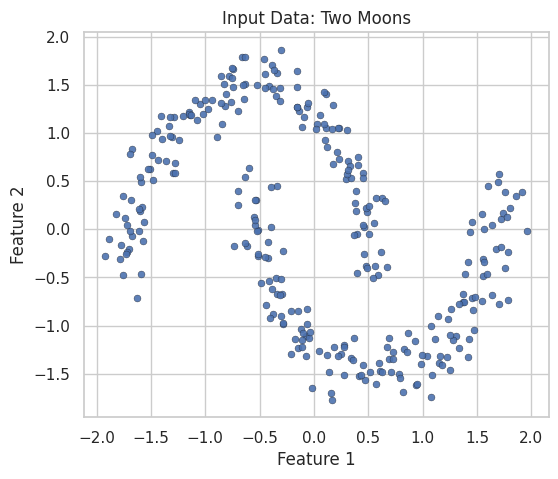

In [3]:
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.9, edgecolors="k", linewidth=0.25)
plt.title("Input Data: Two Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Build and plot dendrogram

A dendrogram visualizes how clusters merge over distance.

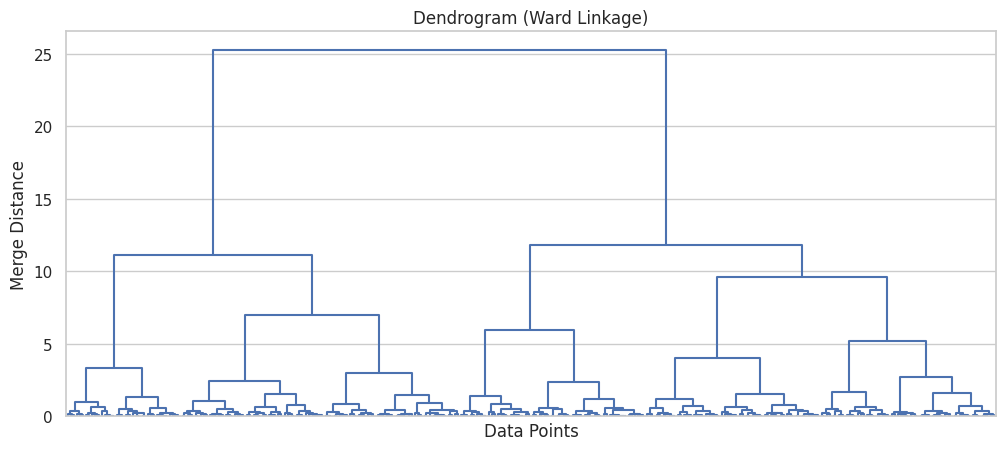

In [4]:
# Linkage matrix using Ward method
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=0)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Merge Distance")
plt.show()

## 3. Cut dendrogram into K clusters

Here we directly set `n_clusters=2` and visualize the result.

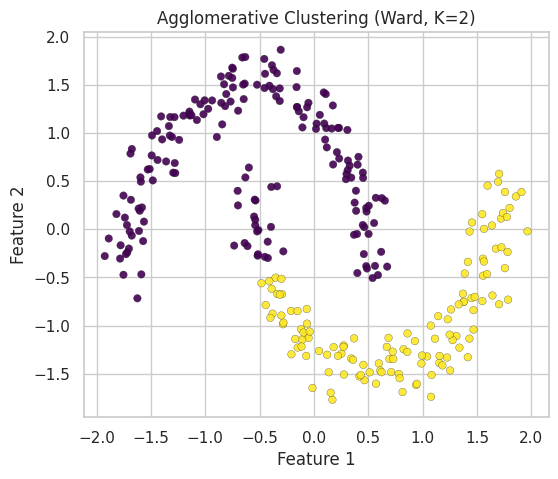

In [5]:
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_hc = hc.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_hc, cmap="viridis", s=30, alpha=0.9, edgecolors="k", linewidth=0.2)
plt.title("Agglomerative Clustering (Ward, K=2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Compare linkage methods

Different linkage rules can produce different cluster shapes.

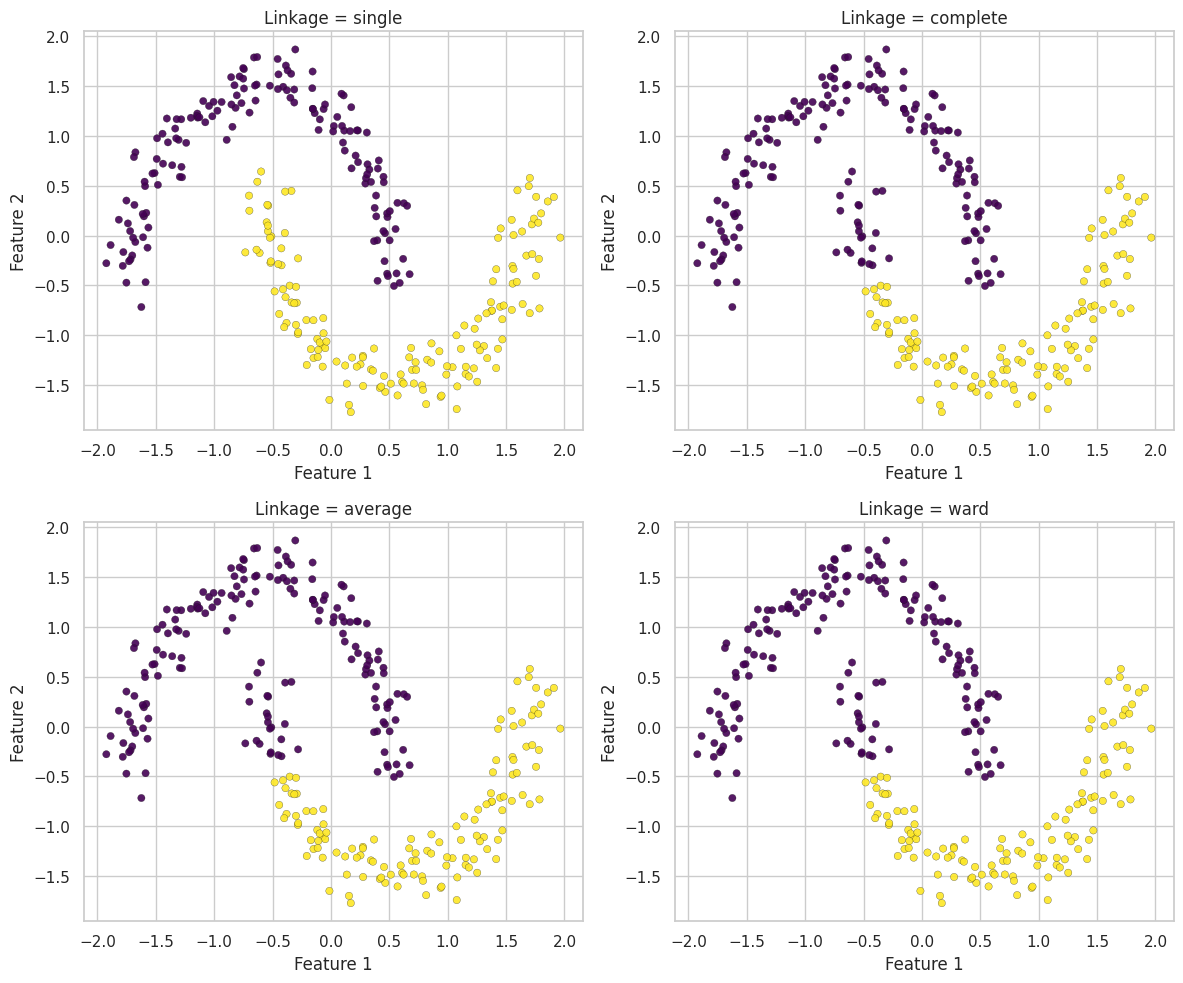

In [6]:
linkages = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, link in zip(axes.ravel(), linkages):
    model = AgglomerativeClustering(n_clusters=2, linkage=link)
    y = model.fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=28, alpha=0.9, edgecolors="k", linewidth=0.2)
    ax.set_title(f"Linkage = {link}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## 5. Compare Hierarchical vs K-Means

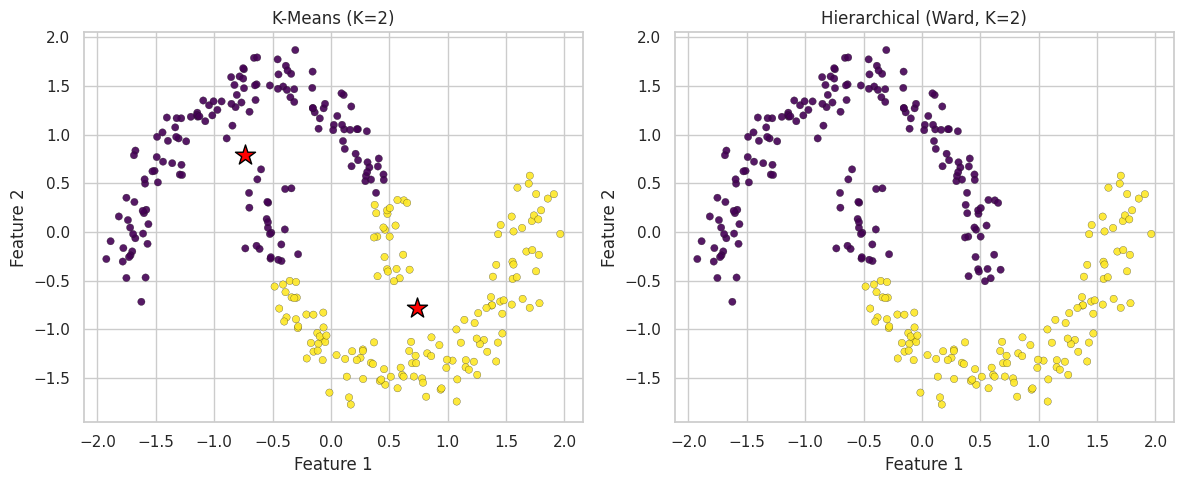

In [7]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km.fit_predict(X)

hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_hc = hc.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap="viridis", s=28, alpha=0.9, edgecolors="k", linewidth=0.2)
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c="red", marker="*", s=230, edgecolors="black")
axes[0].set_title("K-Means (K=2)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_hc, cmap="viridis", s=28, alpha=0.9, edgecolors="k", linewidth=0.2)
axes[1].set_title("Hierarchical (Ward, K=2)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## 6. Dendrogram with candidate cut lines

Horizontal lines represent possible cut thresholds for different numbers of clusters.

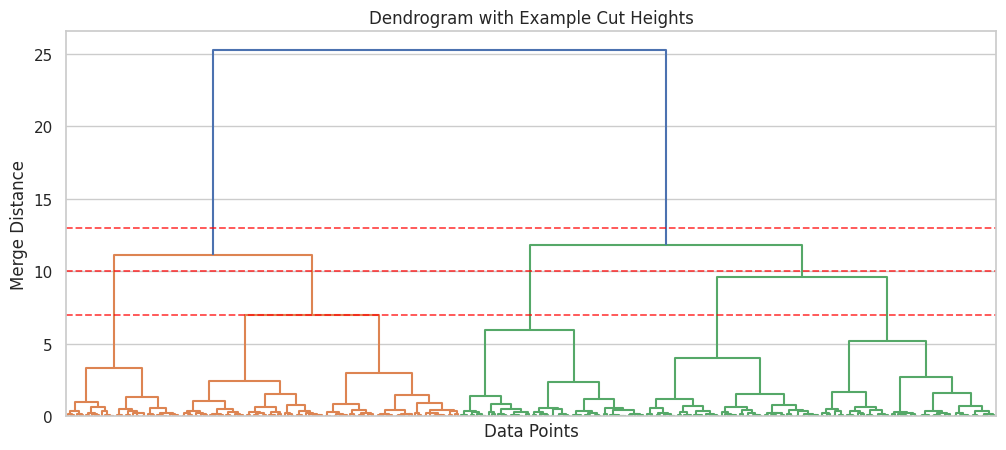

In [8]:
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)

for y in [7, 10, 13]:
    plt.axhline(y=y, color="red", linestyle="--", linewidth=1.3, alpha=0.7)

plt.title("Dendrogram with Example Cut Heights")
plt.xlabel("Data Points")
plt.ylabel("Merge Distance")
plt.show()

## 7. Try another dataset (blobs)

You can test hierarchical clustering on spherical data too.

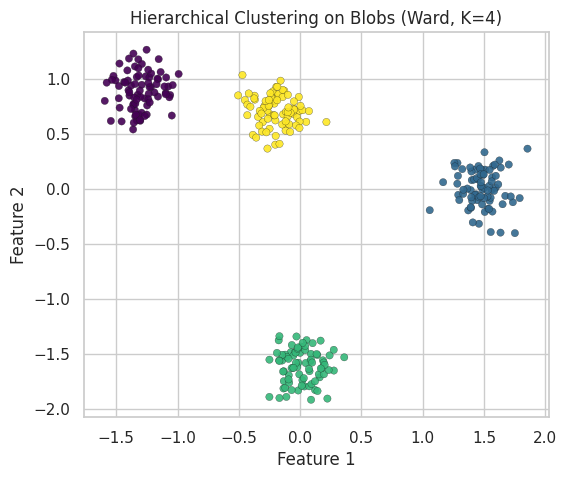

In [9]:
Xb, _ = make_blobs(n_samples=320, centers=4, cluster_std=0.9, random_state=7)
Xb = StandardScaler().fit_transform(Xb)

model = AgglomerativeClustering(n_clusters=4, linkage="ward")
yb = model.fit_predict(Xb)

plt.figure(figsize=(6, 5))
plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="viridis", s=28, alpha=0.9, edgecolors="k", linewidth=0.2)
plt.title("Hierarchical Clustering on Blobs (Ward, K=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 8. Exercises

1. Change `n_clusters` from 2 to 3 on the moon dataset and explain what happens.
2. Try `single` linkage with higher noise and observe chaining behavior.
3. Increase sample size to 2000 and compare runtime against K-Means.
4. Pick your own cut height on the dendrogram and infer cluster count.